<a href="https://colab.research.google.com/github/shristea7/College-Dump/blob/main/AI_Lab5_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import heapq
import matplotlib.pyplot as plt
import networkx as nx

In [ ]:
def manhantan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

In [ ]:
def best_first_search(grid_size, start, treasure):
    visited = set()
    parent = {}
    pq = []

    heapq.heappush(pq, (abs(start[0]-treasure[0]) + abs(start[1]-treasure[1]), start))
    parent[start] = None
    found = False

    while pq:
        h, current = heapq.heappop(pq)

        if current in visited:
            continue

        visited.add(current)
        print(f"Visiting {current}, Heuristic = {h}")

        if current == treasure:
            print("Treasure found!")
            found = True
            break

        x, y = current
        for dx, dy in [(-1,0), (1,0), (0,-1), (0,1)]:
            nx, ny = x + dx, y + dy
            neighbor = (nx, ny)

            if 0 <= nx < grid_size and 0 <= ny < grid_size:
                if neighbor not in visited:
                    if neighbor not in parent:
                        parent[neighbor] = current
                    heapq.heappush(
                        pq,
                        (abs(nx-treasure[0]) + abs(ny-treasure[1]), neighbor)
                    )
    return visited, parent, found


In [ ]:
def reconstruct_path(parent, start, goal):
    path = []
    current = goal
    while current is not None:
        path.append(current)
        current = parent[current]
    path.reverse()
    return path

In [ ]:
def visualize_grid(grid_size, visited, path, start, treasure):
    G = nx.grid_2d_graph(grid_size, grid_size)

    pos = {(x, y): (y, -x) for x, y in G.nodes()}

    node_colors = []
    for node in G.nodes():
        if node == start:
            node_colors.append("green")
        elif node == treasure:
            node_colors.append("gold")
        elif node in path:
            node_colors.append("red")
        elif node in visited:
            node_colors.append("lightblue")
        else:
            node_colors.append("white")

    plt.figure(figsize=(7, 7))
    nx.draw(
        G, pos,
        node_color=node_colors,
        node_size=700,
        edgecolors="black",
        with_labels=True
    )

    plt.title("Best-First Search Treasure Hunt")
    plt.show()


Enter grid size: 3
Enter start X coordinate: 3
Enter start Y coordinate: 1
Enter treasure X coordinate: 2
Enter treasure Y coordinate: 2
Visiting (3, 1), Heuristic = 2
Visiting (2, 1), Heuristic = 1
Visiting (2, 2), Heuristic = 0
🎉 Treasure found!


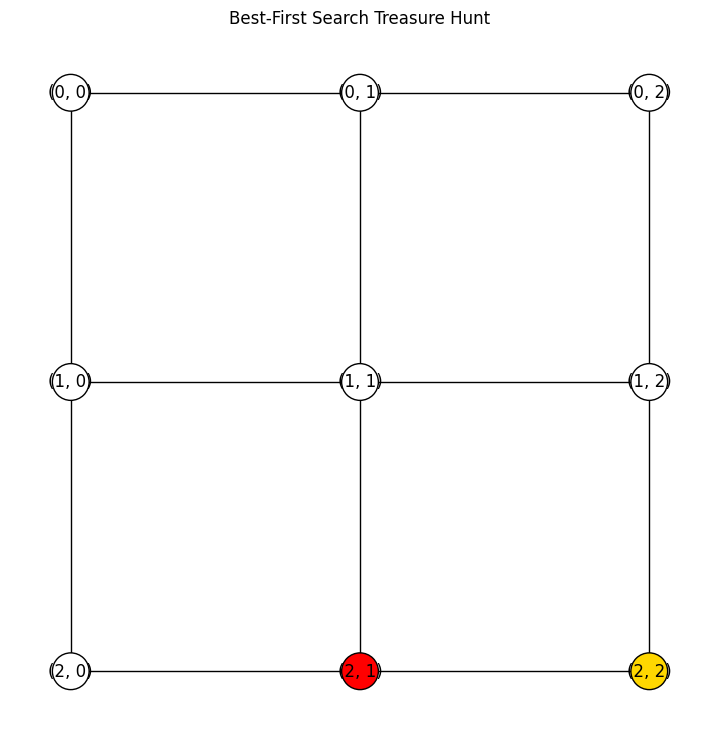

In [ ]:

grid_size = int(input("Enter grid size: "))

sx = int(input("Enter start X coordinate: "))
sy = int(input("Enter start Y coordinate: "))

tx = int(input("Enter treasure X coordinate: "))
ty = int(input("Enter treasure Y coordinate: "))

start = (sx, sy)
treasure = (tx, ty)

visited, parent, found = best_first_search(grid_size, start, treasure)

if found:
    path = reconstruct_path(parent, start, treasure)
    visualize_grid(grid_size, visited, path, start, treasure)
else:
    print(" Treasure not reachable")


